In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=32
sfreq=64
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.1, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014009()
subject, session, run = 1, "session_0", "run_0"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Not setting metadata
576 matching events found
No baseline correction applied


Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.797 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


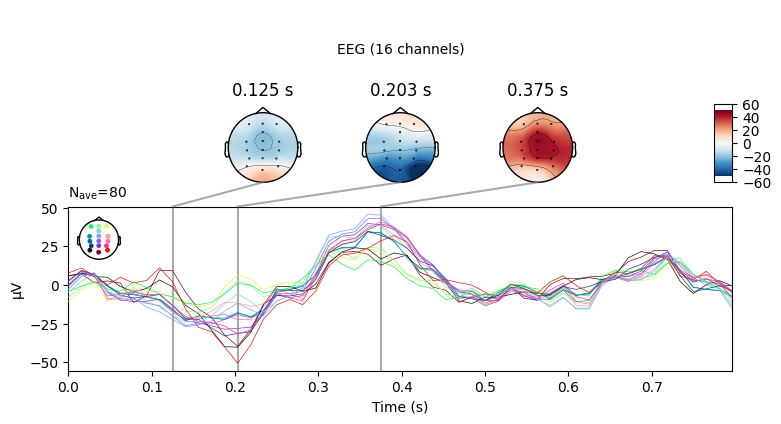

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
split = len(epochs)//2
epochs_train = epochs[:split]
epochs_test = epochs[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('cupy')

X_train = tl.tensor(epochs_train.get_data().astype(np.float32))
y_train = labels_train
X_test = tl.tensor(epochs_test.get_data().astype(np.float32))
y_test = labels_test

X_train /= np.std(X_train, axis=0)[np.newaxis,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:]

In [24]:
hoda = HODA(max_iter=128, rank=(2,2), tol=1e-6,
            initialize ='svd', verbose=True,
            shrinkage=('oas', 'oas'), toeplitz=(1,), solver='ratio_svd')
#%lprun -f  hoda.fit hoda.fit(X_train,y_train)
hoda.fit(X_train,y_train)


[0/128]  shrinkage=0.0090  shrinkage=0.1313  step=1.9750e+00
[1/128]  shrinkage=0.0106  shrinkage=0.3500  step=2.2181e+00
[2/128]  shrinkage=0.0095  shrinkage=0.2135  step=1.4305e+00
[3/128]  shrinkage=0.0099  shrinkage=0.3087  step=1.5693e+00
[4/128]  shrinkage=0.0096  shrinkage=0.2534  step=1.3276e+00
[5/128]  shrinkage=0.0098  shrinkage=0.2805  step=4.9413e-01
[6/128]  shrinkage=0.0097  shrinkage=0.2640  step=3.9051e-01
[7/128]  shrinkage=0.0098  shrinkage=0.2701  step=3.0916e-01
[8/128]  shrinkage=0.0097  shrinkage=0.2653  step=2.5284e-01
[9/128]  shrinkage=0.0098  shrinkage=0.2664  step=2.0710e-01
[10/128]  shrinkage=0.0098  shrinkage=0.2650  step=1.6952e-01
[11/128]  shrinkage=0.0098  shrinkage=0.2651  step=1.4009e-01
[12/128]  shrinkage=0.0098  shrinkage=0.2646  step=1.1355e-01
[13/128]  shrinkage=0.0098  shrinkage=0.2646  step=9.4105e-02
[14/128]  shrinkage=0.0098  shrinkage=0.2644  step=7.5477e-02
[15/128]  shrinkage=0.0098  shrinkage=0.2644  step=6.2621e-02
[16/128]  shrinkag

HODA(max_iter=128, rank=(2, 2), shrinkage=('oas', 'oas'), solver='ratio_svd',
     toeplitz=(1,), tol=1e-06, verbose=True)

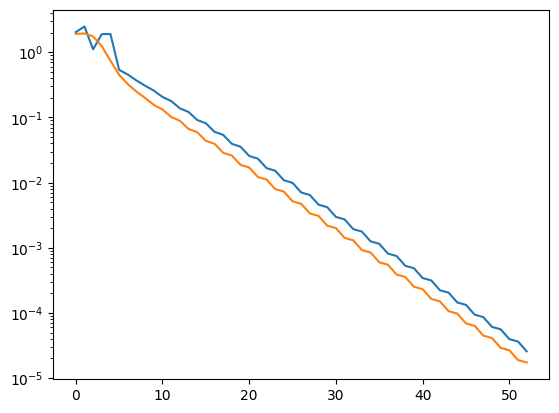

In [25]:
import cupy

plt.semilogy(cupy.asnumpy(hoda.updates_[:,:hoda.iter_]))
plt.show()

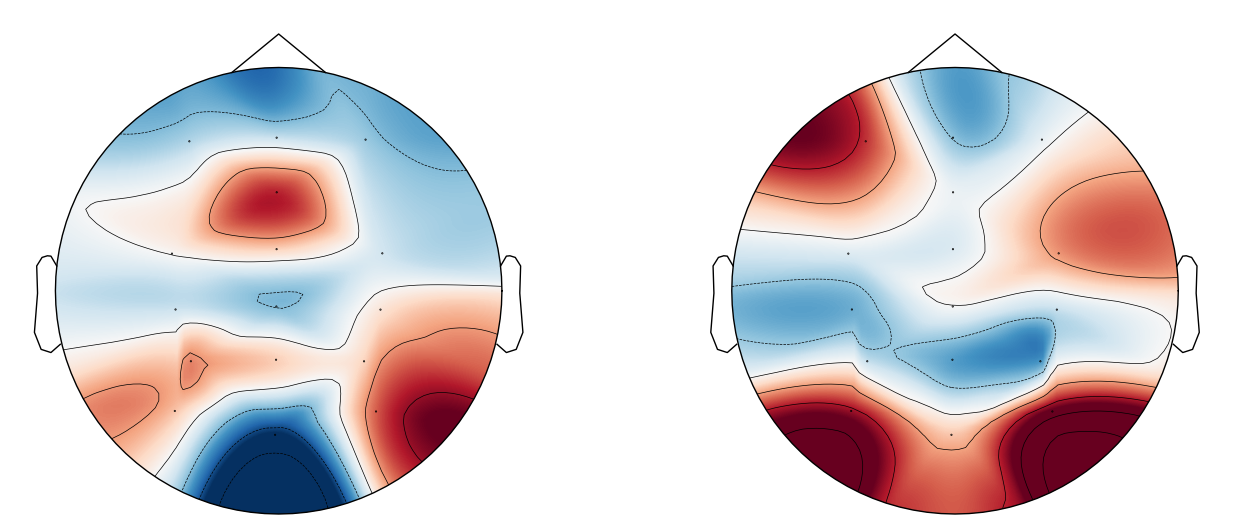

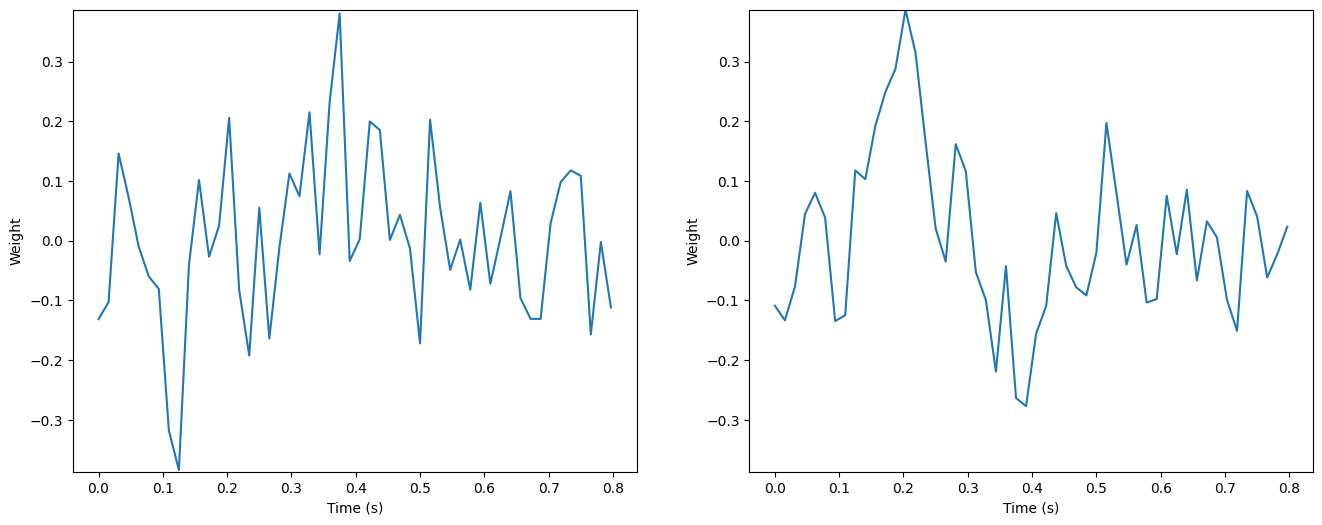

In [26]:
fig, axs = plt.subplots(1,hoda.rank_[0], figsize=(16,6))
for i in range(hoda.rank_[0]):
    w = cupy.asnumpy(hoda.projs_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[i], show=False)
vmax = np.max(np.abs(hoda.projs_[1]))
fig, axs = plt.subplots(1,hoda.rank_[1], figsize=(16,6))
for i in range(hoda.rank_[1]):
    w = cupy.asnumpy(hoda.projs_[1][:,i])
    axs[i].plot(epochs.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')
    axs[i].set_ylim([-vmax, vmax])


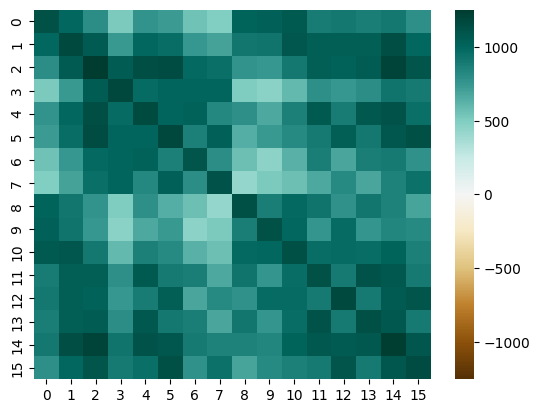

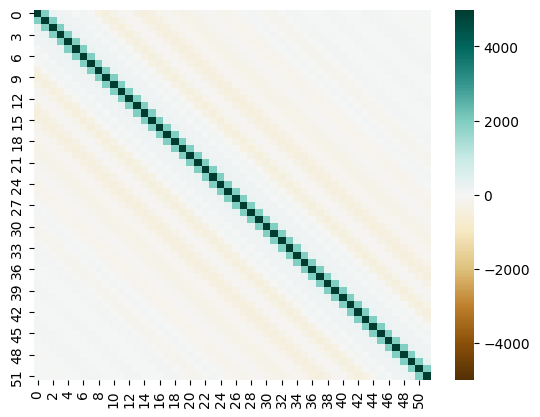

In [27]:
for k in range(2):
    cov = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

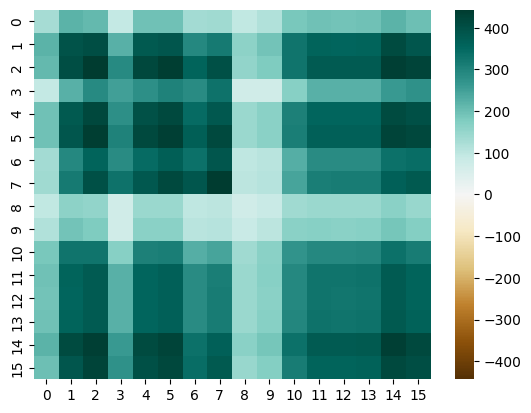

In [ ]:
for k in range(2):
    cov = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

In [ ]:
patterns = [hoda.scatter_w_[k] @ p for k,p in enumerate(hoda.projs_)]

fig, axs = plt.subplots(1,hoda.rank_[0], figsize=(16,6))
for i in range(hoda.rank_[0]):
    w = cupy.asnumpy(patterns[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[i], show=False)
vmax = np.max(np.abs(patterns[1]))
fig, axs = plt.subplots(1,hoda.rank_[1], figsize=(16,6))
for i in range(hoda.rank_[1]):
    w = cupy.asnumpy(patterns[1][:,i])
    axs[i].plot(epochs.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')
    axs[i].set_ylim([-vmax, vmax])

In [14]:
Xt_train = cupy.asnumpy(hoda.transform(X_train))
Xt_test = cupy.asnumpy(hoda.transform(X_test))

Xt_train = Xt_train.reshape((Xt_train.shape[0],-1))
Xt_test = Xt_test.reshape((Xt_test.shape[0],-1))

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.svm import SVC

classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)


LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')

In [16]:
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()
f1 = feature_order[0]
f2 = feature_order[1]

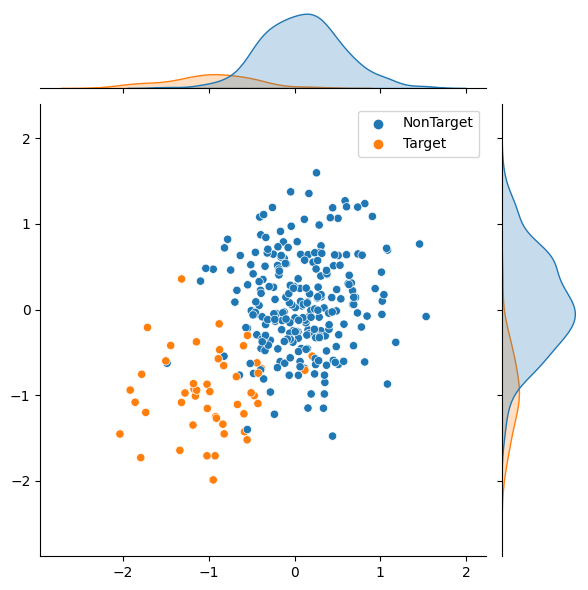

In [17]:
import seaborn as sns

g = sns.jointplot(x=Xt_train[:,f1],y=Xt_train[:,f2], hue=y_train)

In [18]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

0.9885416666666667

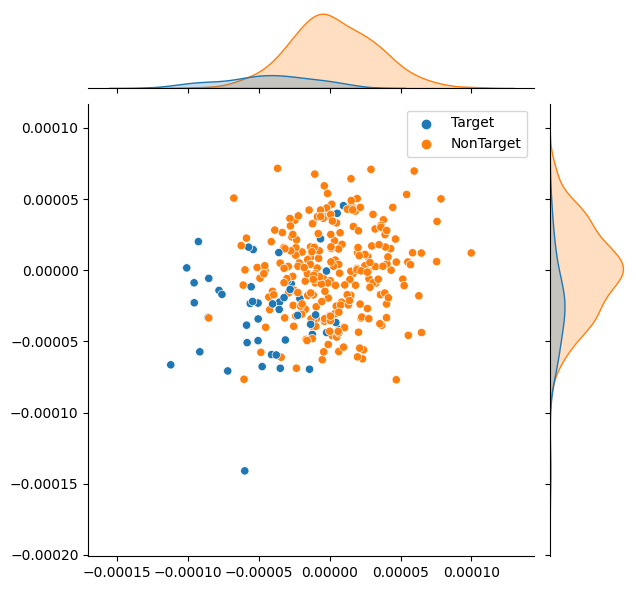

In [19]:
g = sns.jointplot(x=Xt_test[:,f1],y=Xt_test[:,f2], hue=y_test)

In [20]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.9092013888888889